<a href="https://colab.research.google.com/github/RafaihAbbasi/Heart-Disease-Prediction-Task-03/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# --- STEP 1: DATA LOADING & CLEANING ---
import pandas as pd
import numpy as np

# 1. Load the dataset (Ensures 'df' is defined in this session)
df = pd.read_csv('heart_disease_uci.csv')

# 2. Drop the 'id' column as it's just an index and doesn't help prediction
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# 3. Handle missing values for numeric columns by filling them with the median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# 4. Handle missing values for categorical columns by filling them with the mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 5. Convert the target 'num' to a binary classification problem (0 = No Disease, 1 = Heart Disease)
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df = df.drop(columns=['num']) # drop original num column

# 6. Convert categorical text columns into numbers using One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

print("Preprocessing Complete!")
print(f"New dataset shape after encoding: {df_encoded.shape}")

Preprocessing Complete!
New dataset shape after encoding: (920, 22)


/tmp/ipykernel_4411/4169038587.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


/tmp/ipykernel_4411/2167873402.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='pastel')


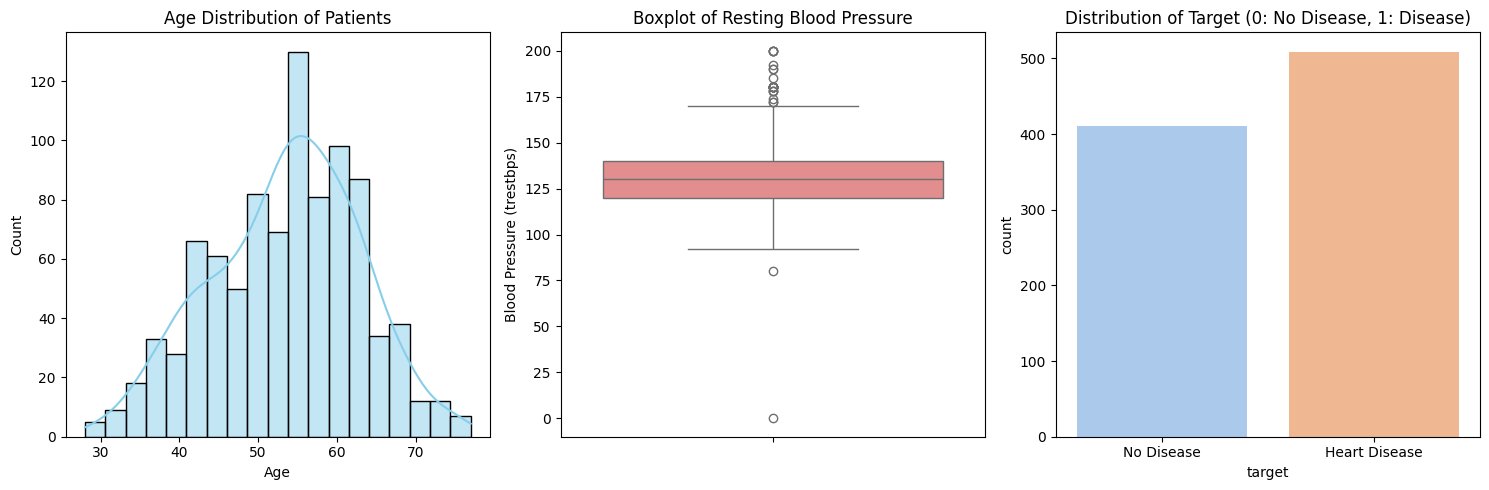

In [3]:
# --- STEP 2: EXPLORATORY DATA ANALYSIS (EDA) ---
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the plotting area
plt.figure(figsize=(15, 5))

# 1. Histogram: Age Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['age'], kde=True, color='skyblue')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')

# 2. Box Plot: Outliers in Resting Blood Pressure
plt.subplot(1, 3, 2)
sns.boxplot(y=df['trestbps'], color='lightcoral')
plt.title('Boxplot of Resting Blood Pressure')
plt.ylabel('Blood Pressure (trestbps)')

# 3. Bar Plot: Target Balance (Heart Disease vs No Disease)
plt.subplot(1, 3, 3)
sns.countplot(x='target', data=df, palette='pastel')
plt.title('Distribution of Target (0: No Disease, 1: Disease)')
plt.xticks([0, 1], ['No Disease', 'Heart Disease'])

plt.tight_layout()
plt.show()

In [4]:
# --- STEP 3: MODEL TRAINING ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# 1. Separate features (X) and target variable (y)
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

# 2. Split into 80% Training and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize models
log_reg = LogisticRegression(max_iter=2000)
dec_tree = DecisionTreeClassifier(max_depth=5, random_state=42)

# 4. Train models
log_reg.fit(X_train, y_train)
dec_tree.fit(X_train, y_train)

print("Both Logistic Regression and Decision Tree models have been trained successfully!")

Both Logistic Regression and Decision Tree models have been trained successfully!


Logistic Regression Accuracy: 82.61%
Decision Tree Accuracy:       82.07%



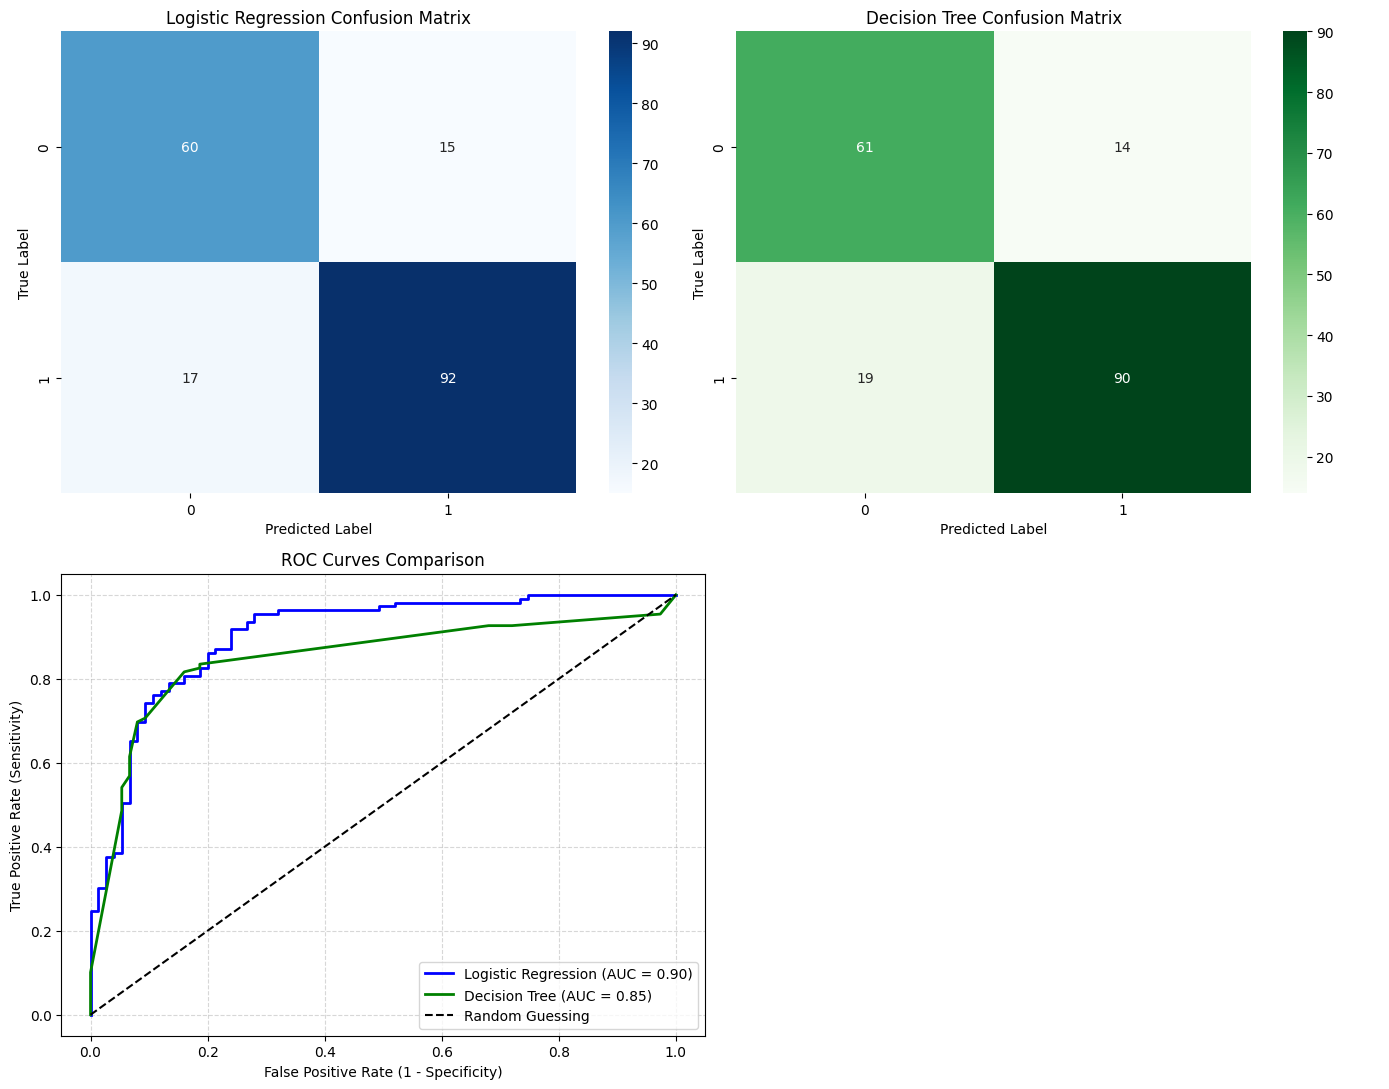

In [5]:
# --- STEP 4: MODEL EVALUATION ---
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# 1. Generate predictions on the test data
y_pred_lr = log_reg.predict(X_test)
y_pred_dt = dec_tree.predict(X_test)

# 2. Get prediction probabilities (needed for the ROC Curve)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
y_prob_dt = dec_tree.predict_proba(X_test)[:, 1]

# 3. Print the Accuracy scores
print("=========================================")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")
print(f"Decision Tree Accuracy:       {accuracy_score(y_test, y_pred_dt) * 100:.2f}%")
print("=========================================\n")

# 4. Plot Confusion Matrices and ROC Curves side-by-side
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Top Left: Logistic Regression Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Logistic Regression Confusion Matrix')
axes[0,0].set_xlabel('Predicted Label')
axes[0,0].set_ylabel('True Label')

# Top Right: Decision Tree Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens', ax=axes[0,1])
axes[0,1].set_title('Decision Tree Confusion Matrix')
axes[0,1].set_xlabel('Predicted Label')
axes[0,1].set_ylabel('True Label')

# Bottom Left: ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

axes[1,0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.2f})', color='blue', lw=2)
axes[1,0].plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc(fpr_dt, tpr_dt):.2f})', color='green', lw=2)
axes[1,0].plot([0, 1], [0, 1], 'k--', label='Random Guessing')
axes[1,0].set_title('ROC Curves Comparison')
axes[1,0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1,0].set_ylabel('True Positive Rate (Sensitivity)')
axes[1,0].legend()
axes[1,0].grid(True, linestyle='--', alpha=0.5)

# Bottom Right: Turn off the empty subplot window to keep the layout clean
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4411/1940260300.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


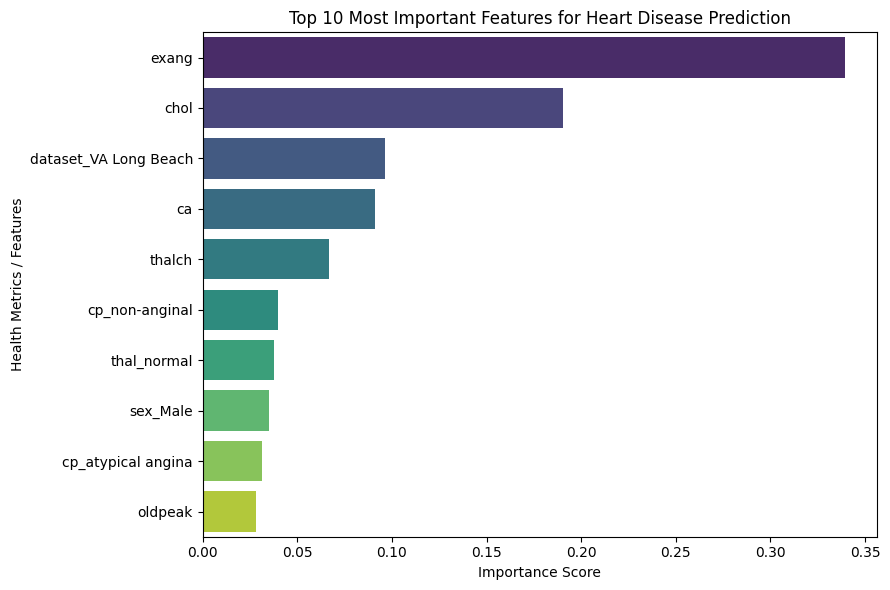

In [6]:
# --- STEP 5: FEATURE IMPORTANCE ---

# 1. Get the feature importances from the trained decision tree
importances = dec_tree.feature_importances_
feature_names = X.columns

# 2. Organize them into a DataFrame and grab the top 10
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Plot the importances
plt.figure(figsize=(9, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Top 10 Most Important Features for Heart Disease Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Health Metrics / Features')
plt.tight_layout()
plt.show()